# IDRA Day 14 - Food Delivery Data Visualization Portfolio

## Assignment

Food Delivery Business Performance Data Visualization using Matplotlib and Seaborn.

### Objectives

- Understand the Food Delivery dataset
- Explore trends in orders and revenue
- Compare cities and cuisines
- Analyze marketing spend and revenue
- Analyze delivery time and customer ratings
- Study the effect of weather on performance
- Compare different order channels
- Create different types of visualizations
- Interpret insights from each visualization

## Libraries Used

- Pandas
- Matplotlib
- Seaborn
- NumPy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv


In [3]:
df = pd.read_csv('/content/Day14_Food_Delivery_Visualization_Dataset.csv')

df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [4]:
df.shape

(360, 16)

In [5]:
df.columns

Index(['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine',
       'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue',
       'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes',
       'Customer_Rating', 'Repeat_Customer_Percent'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          3

In [7]:
df.describe()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


In [8]:
df.isnull().sum()

,0
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Date'].head()

,Date
0,2025-03-22
1,2025-04-15
2,2025-01-26
3,2025-06-20
4,2025-08-07


In [11]:
print("Total Orders:", df['Orders'].sum())
print("Total Revenue:", df['Revenue'].sum())
print("Average Order Value:", df['Average_Order_Value'].mean())
print("Average Delivery Time:", df['Avg_Delivery_Minutes'].mean())
print("Average Customer Rating:", df['Customer_Rating'].mean())

Total Orders: 53153
Total Revenue: 21812801.32
Average Order Value: 409.15108333333336
Average Delivery Time: 32.5775
Average Customer Rating: 4.452861111111111


##Visualization 1 — Line Plot: Orders Over Time

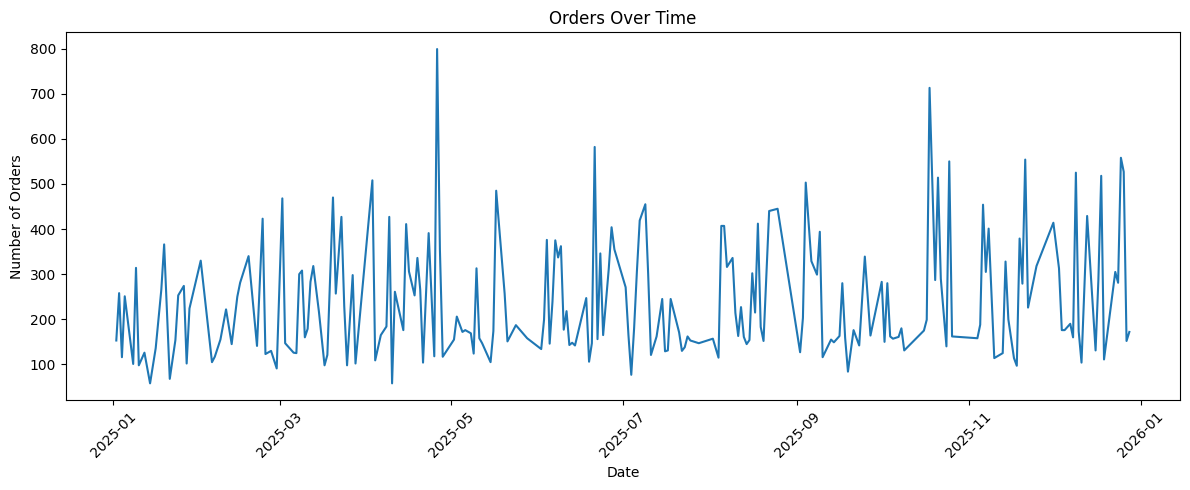

In [12]:
daily_orders = df.groupby('Date')['Orders'].sum()

plt.figure(figsize=(12, 5))

plt.plot(daily_orders.index, daily_orders.values)

plt.title('Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

The line plot shows how the number of food delivery orders changes over time.

There are noticeable fluctuations in daily orders, with some periods showing higher demand than others. This indicates that order demand varies across the year and can be influenced by seasonality, promotions, or other business factors.

##Visualization 2 — Line Plot: Revenue Over Time

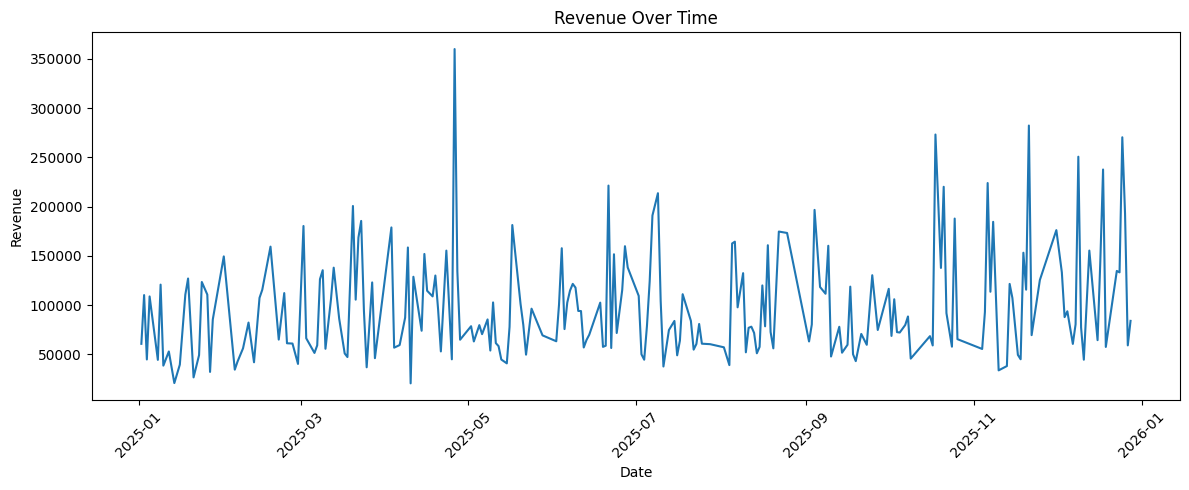

In [13]:
daily_revenue = df.groupby('Date')['Revenue'].sum()

plt.figure(figsize=(12, 5))

plt.plot(daily_revenue.index, daily_revenue.values)

plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Revenue changes over time along with order activity. Periods with higher order volumes generally produce higher revenue.

The chart can help the business identify high-performing and low-performing periods.

##Visualization 3 — Bar Chart: Revenue by City

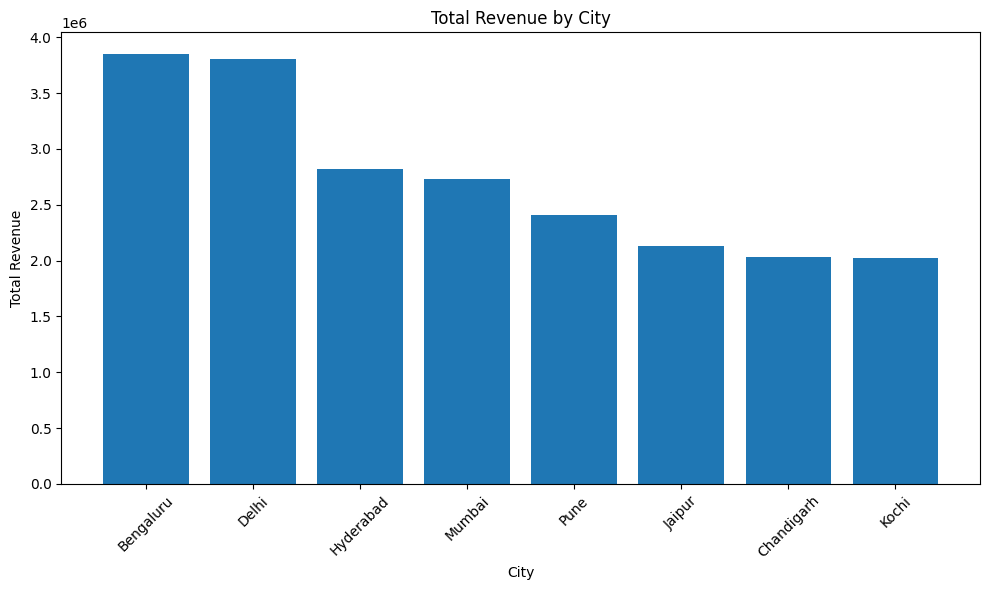

In [14]:
city_revenue = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(city_revenue.index, city_revenue.values)

plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Bengaluru generates the highest total revenue among the cities in the dataset, followed closely by Delhi.

Kochi and Chandigarh generate comparatively lower total revenue.

This suggests that Bengaluru and Delhi are important markets for the food delivery business.

##Visualization 4 — Bar Chart: Orders by Cuisine

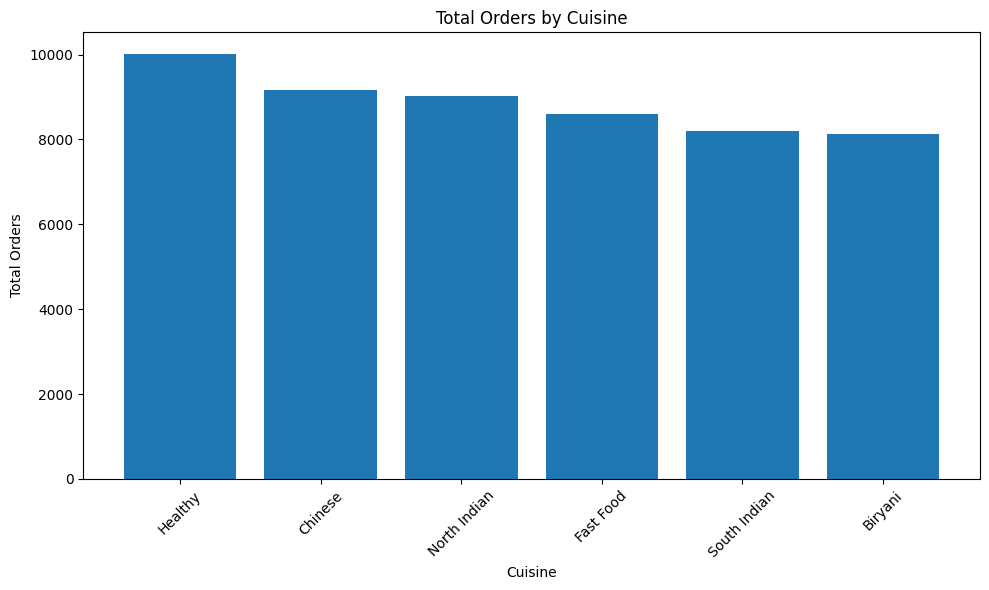

In [15]:
cuisine_orders = df.groupby('Cuisine')['Orders'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(cuisine_orders.index, cuisine_orders.values)

plt.title('Total Orders by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Healthy cuisine has the highest number of orders, followed by North Indian and Chinese cuisine.

Fast Food has the lowest total orders among the cuisines in this dataset.

This indicates stronger customer demand for healthier food options.

##Visualization 5 — Bar Chart: Revenue by Cuisine

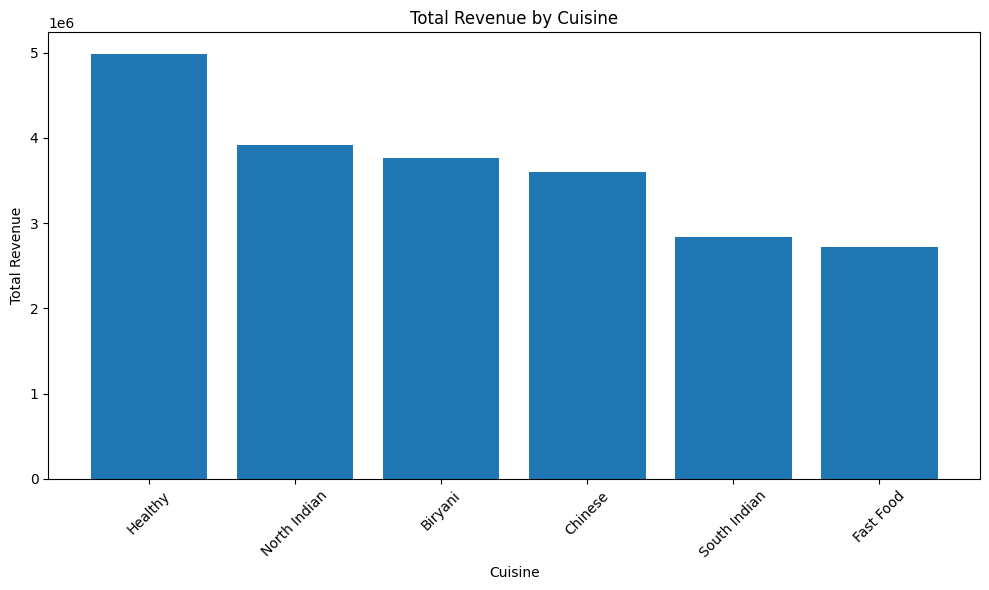

In [16]:
cuisine_revenue = df.groupby('Cuisine')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(cuisine_revenue.index, cuisine_revenue.values)

plt.title('Total Revenue by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Healthy cuisine generates the highest revenue among the cuisines.

North Indian and Biryani also contribute substantially to total revenue.

Healthy cuisine is therefore one of the strongest performing cuisine categories in the dataset.

##Visualization 6 — Scatter Plot: Marketing Spend vs Revenue

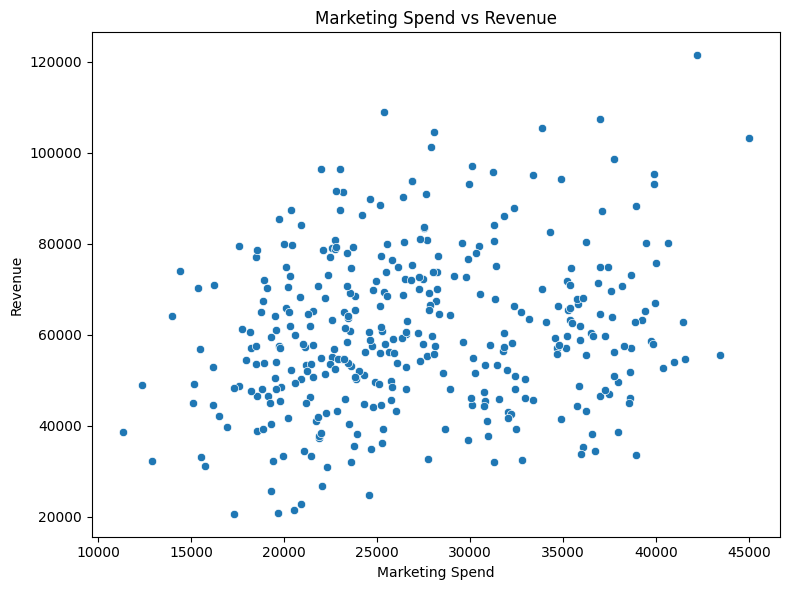

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue'
)

plt.title('Marketing Spend vs Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows the relationship between marketing spending and revenue.

There is a positive relationship, but it is not extremely strong. Higher marketing spending tends to be associated with higher revenue in some cases, but marketing spend alone does not explain all revenue differences.

##Visualization 7 — Histogram: Revenue Distribution

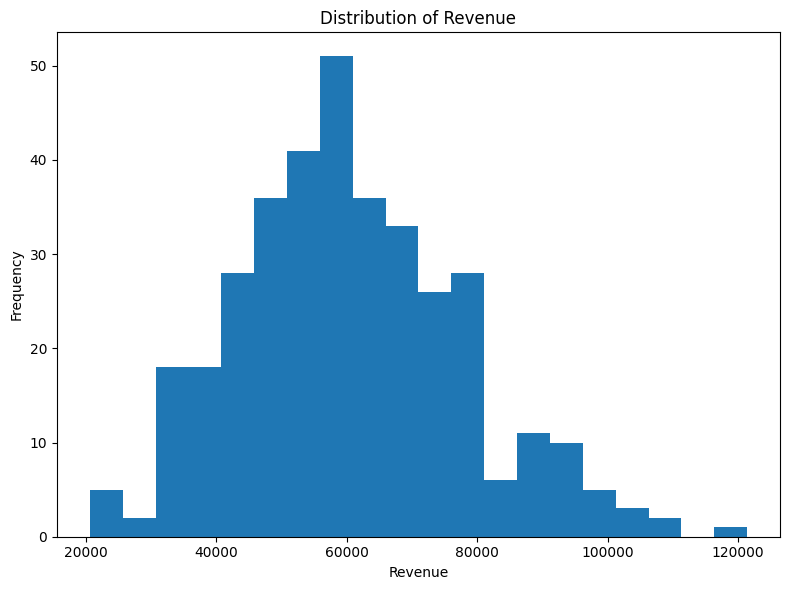

In [18]:
plt.figure(figsize=(8, 6))

plt.hist(df['Revenue'], bins=20)

plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation

The histogram shows how revenue values are distributed across the dataset.

Most observations are concentrated within a certain revenue range, while fewer observations occur at the extreme values.

##Visualization 8 — Histogram: Delivery Time

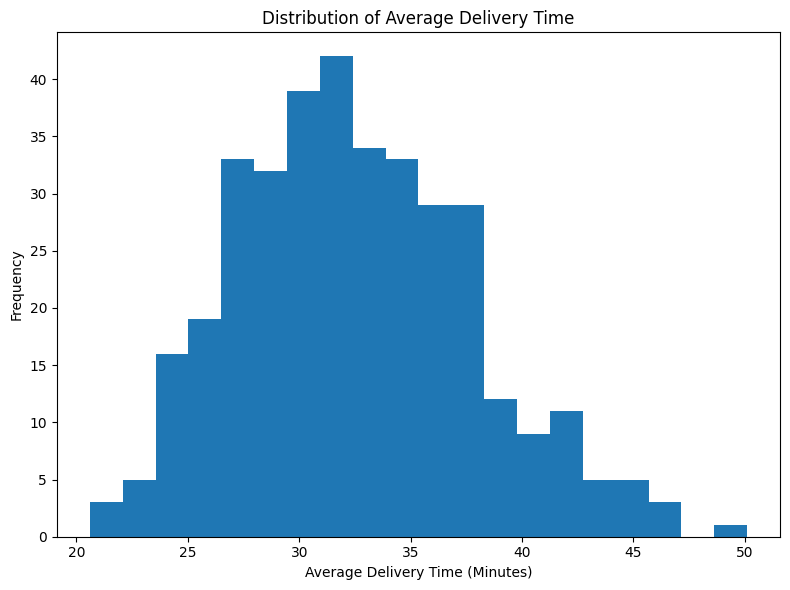

In [19]:
plt.figure(figsize=(8, 6))

plt.hist(df['Avg_Delivery_Minutes'], bins=20)

plt.title('Distribution of Average Delivery Time')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation

The delivery time values are distributed across different time ranges.

Most deliveries fall within a moderate delivery-time range, while some observations have longer delivery times.

##Visualization 9 — Box Plot: Revenue by Cuisine

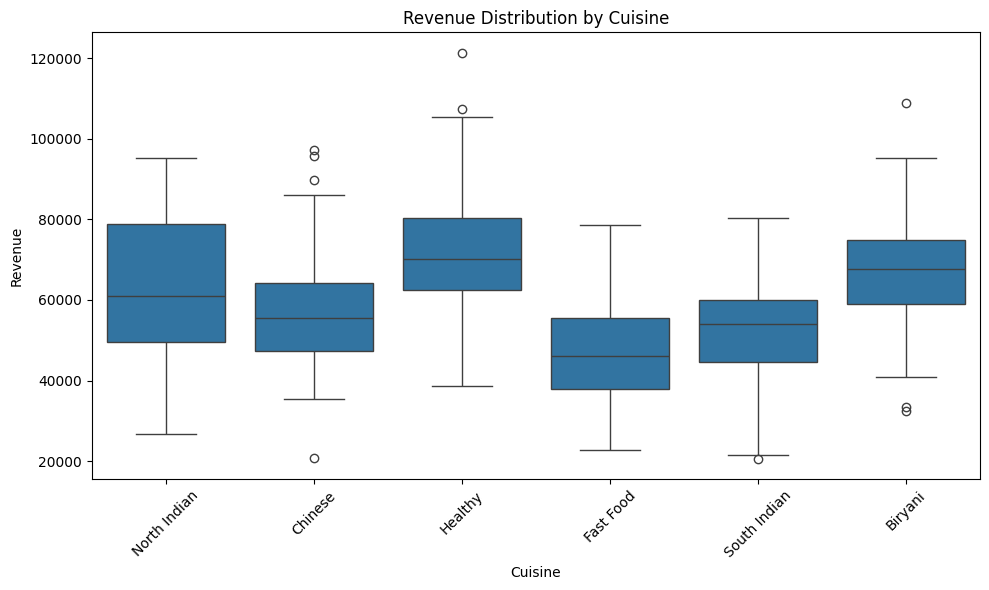

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Cuisine',
    y='Revenue'
)

plt.title('Revenue Distribution by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

The box plot compares the distribution of revenue across different cuisines.

It shows the median, spread and possible extreme values for each cuisine. Some cuisines have wider revenue variation than others.

##Visualization 10 — Violin Plot: Customer Rating by Weather

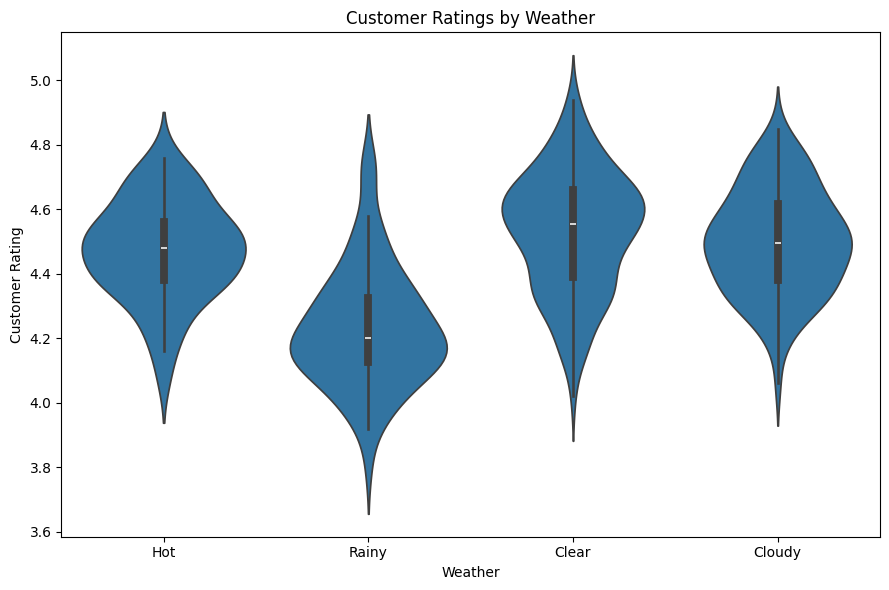

In [21]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x='Weather',
    y='Customer_Rating'
)

plt.title('Customer Ratings by Weather')
plt.xlabel('Weather')
plt.ylabel('Customer Rating')

plt.tight_layout()
plt.show()

### Interpretation

Customer ratings vary across weather conditions.

Rainy weather has the lowest average customer rating, while clear weather has a higher average rating.

This suggests that difficult weather conditions may negatively affect the customer experience.

##Visualization 11 — Count Plot: Order Channel

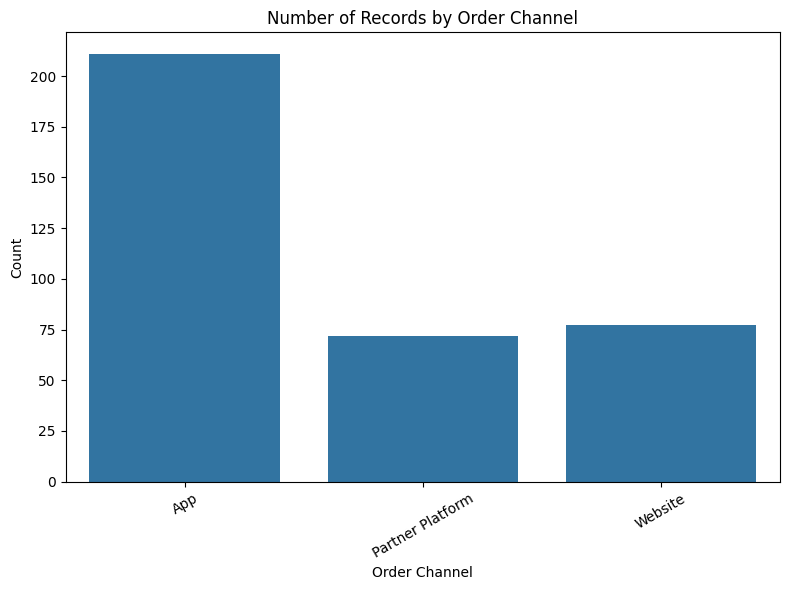

In [22]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='Order_Channel'
)

plt.title('Number of Records by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Count')

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### Interpretation

The chart shows the distribution of records across different order channels.

The App has the largest number of records, indicating that it is an important ordering channel for the business.

##Visualization 12 — Revenue by Order Channel

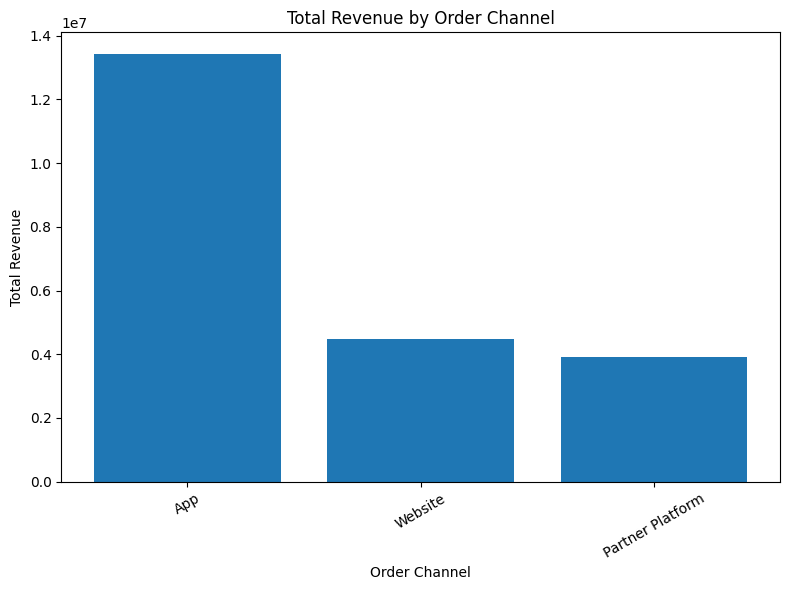

In [23]:
channel_revenue = df.groupby('Order_Channel')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

plt.bar(channel_revenue.index, channel_revenue.values)

plt.title('Total Revenue by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### Interpretation

The App generates the highest total revenue among the order channels.

The Website contributes the second-highest revenue, while Partner Platform generates the lowest revenue.

This shows the importance of the App as a major sales channel.


##Visualization 13 — Weather vs Delivery Time

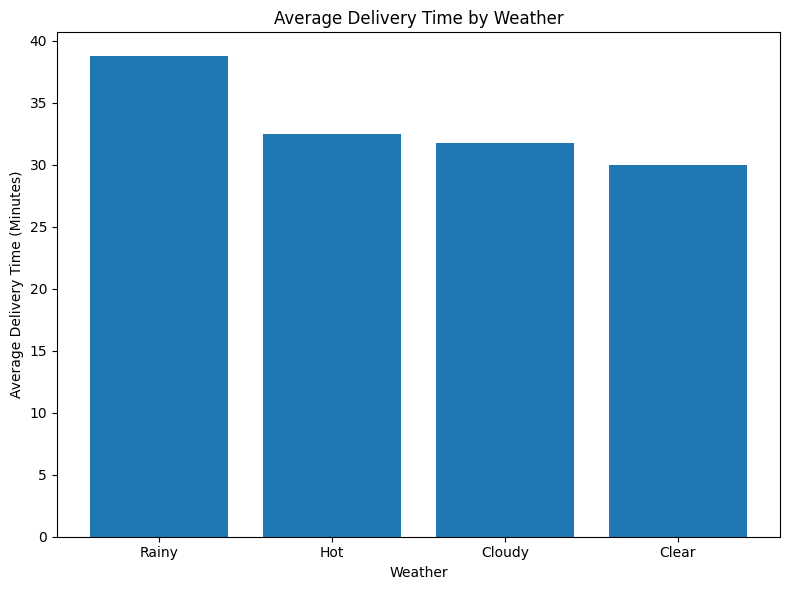

In [24]:
weather_delivery = df.groupby('Weather')['Avg_Delivery_Minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

plt.bar(weather_delivery.index, weather_delivery.values)

plt.title('Average Delivery Time by Weather')
plt.xlabel('Weather')
plt.ylabel('Average Delivery Time (Minutes)')

plt.tight_layout()
plt.show()

### Interpretation

Rainy weather has the highest average delivery time.

Clear weather has the lowest average delivery time.

This suggests that weather conditions can affect delivery efficiency, with rainy conditions creating longer delivery times.

##Visualization 14 — Correlation Heatmap

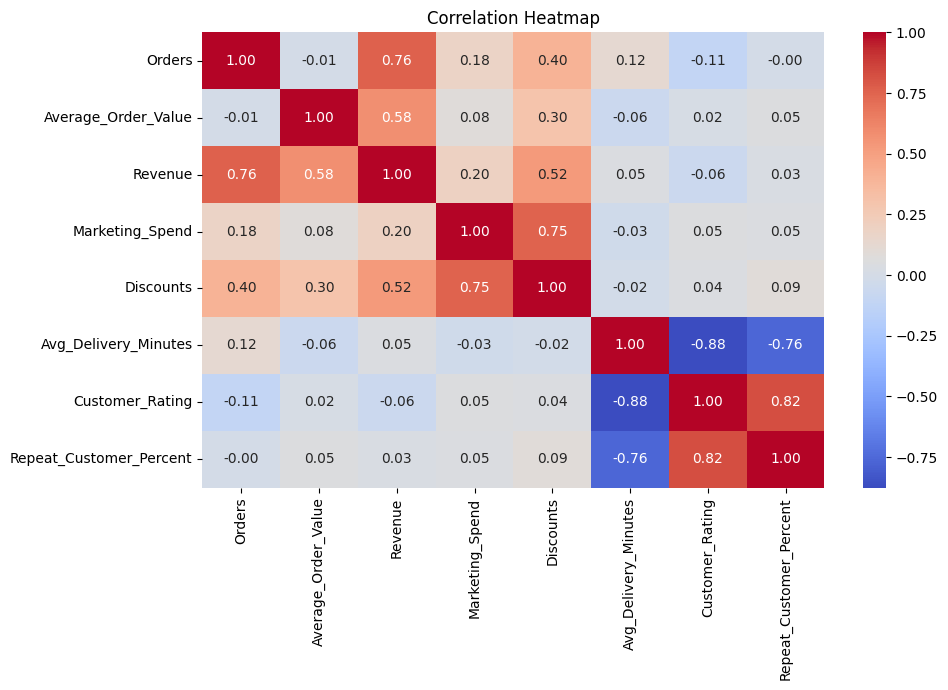

In [25]:
numeric_columns = [
    'Orders',
    'Average_Order_Value',
    'Revenue',
    'Marketing_Spend',
    'Discounts',
    'Avg_Delivery_Minutes',
    'Customer_Rating',
    'Repeat_Customer_Percent'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap shows relationships between the numerical variables.

Orders and Revenue have a strong positive relationship, meaning that higher order volumes are generally associated with higher revenue.

Revenue also has a positive relationship with Discounts.

Marketing Spend has a weaker positive relationship with Revenue.

Customer Rating has very little linear correlation with Revenue, indicating that higher revenue does not necessarily mean higher customer ratings.

##Visualization 15 — Orders vs Revenue

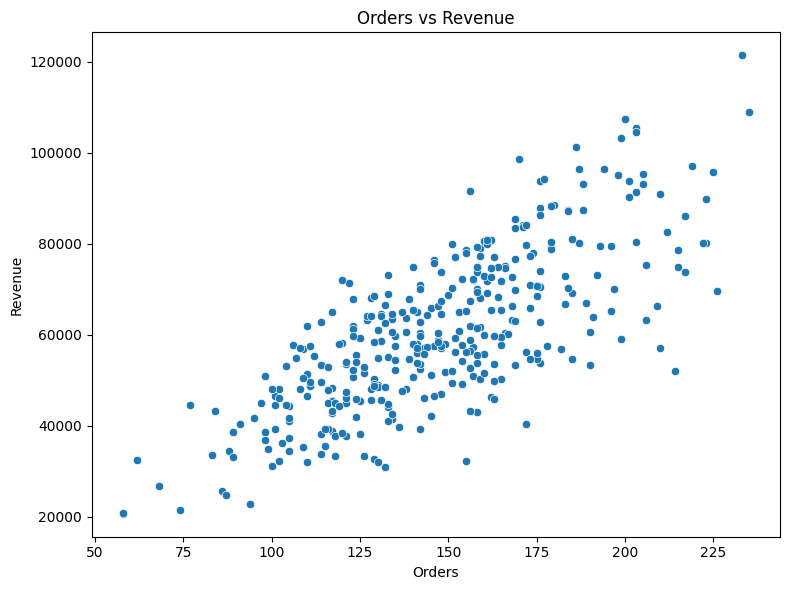

In [26]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Orders',
    y='Revenue'
)

plt.title('Orders vs Revenue')
plt.xlabel('Orders')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

### Interpretation

There is a strong positive relationship between orders and revenue.

As the number of orders increases, revenue generally increases as well.

This indicates that order volume is an important contributor to overall revenue.

##Visualization 16 — Delivery Time vs Customer Rating

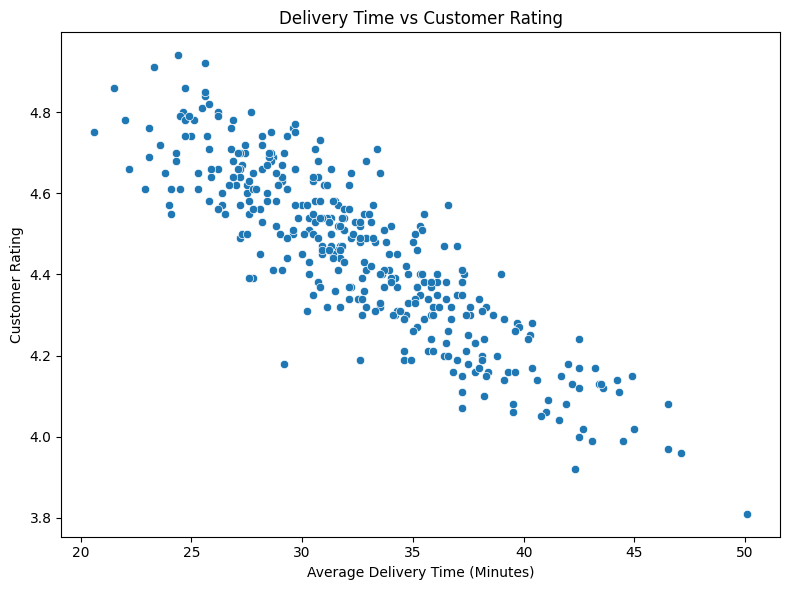

In [27]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Avg_Delivery_Minutes',
    y='Customer_Rating'
)

plt.title('Delivery Time vs Customer Rating')
plt.xlabel('Average Delivery Time (Minutes)')
plt.ylabel('Customer Rating')

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot examines whether delivery time is related to customer ratings.

The relationship is relatively weak in this dataset, although rainy conditions show both longer delivery times and lower average ratings.

Therefore, delivery time may influence customer satisfaction, but it is not the only factor affecting ratings.

##Visualization 17 — Revenue by Weather

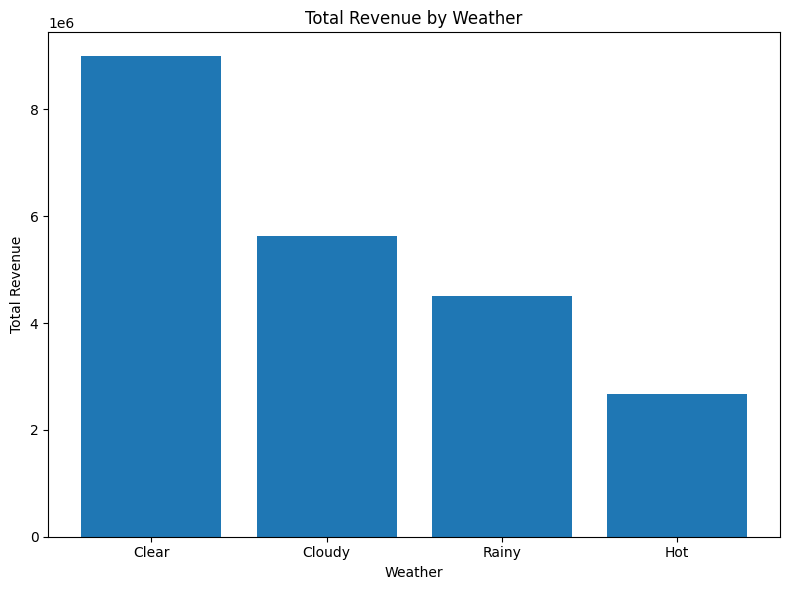

In [28]:
weather_revenue = df.groupby('Weather')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

plt.bar(weather_revenue.index, weather_revenue.values)

plt.title('Total Revenue by Weather')
plt.xlabel('Weather')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### Interpretation

The chart compares total revenue under different weather conditions.

The differences are relatively moderate, suggesting that weather affects operations and delivery time more noticeably than overall revenue.

Important Numerical Relationships

In [29]:
print("Correlation between Orders and Revenue:")
print(df['Orders'].corr(df['Revenue']))

print("\nCorrelation between Marketing Spend and Revenue:")
print(df['Marketing_Spend'].corr(df['Revenue']))

print("\nCorrelation between Delivery Time and Customer Rating:")
print(df['Avg_Delivery_Minutes'].corr(df['Customer_Rating']))

Correlation between Orders and Revenue:
0.7596171918471174

Correlation between Marketing Spend and Revenue:
0.19812719039135182

Correlation between Delivery Time and Customer Rating:
-0.8758810555011177


# Key Findings

1. Bengaluru generated the highest total revenue among the cities.
2. Delhi was the second-highest revenue-generating city.
3. Healthy cuisine recorded the highest number of orders.
4. Healthy cuisine also generated the highest total revenue.
5. The App was the most important order channel and generated the highest revenue.
6. Orders and Revenue have a strong positive relationship.
7. Marketing Spend has a relatively weak positive relationship with Revenue.
8. Rainy weather resulted in the highest average delivery time.
9. Rainy weather also had the lowest average customer rating.
10. Customer Rating has only a weak relationship with delivery time in the overall dataset.
11. Weather appears to have a clearer effect on delivery time and customer experience than on total revenue.
12. Order volume is one of the most important factors associated with revenue.

# Conclusion

The Food Delivery Business Performance Dataset was analyzed using Matplotlib and Seaborn.

Different visualization techniques were used to understand business performance, including line plots, bar charts, scatter plots, histograms, box plots, violin plots, count plots and a correlation heatmap.

The analysis showed that Bengaluru and Delhi are strong revenue-generating cities, while Healthy cuisine is the strongest cuisine category in terms of orders and revenue.

The App is the leading order channel and contributes the highest total revenue.

Orders have a strong positive relationship with revenue, while marketing spend has a weaker relationship with revenue.

Weather conditions also affect delivery operations. Rainy weather has the highest average delivery time and the lowest average customer rating.

Overall, the visualizations provide useful insights into customer demand, revenue performance, order channels, cuisine preferences, delivery operations and customer experience.